# Project Description

The goal of this project is to predict how likely a borrower is to default on a loan using demographic, financial, and loan-related features.

The target variable is "loan_status" with it having two values:
1. 0 = loan has been paid back
2. 1 = load was defaulted

This is a Binary Classification because there are only two outcomes, namely: default vs non-default.

# Imports/Dependencies

# Important Libraries

- <b><u>Pandas</u></b>: Used to handle the dataset and helps with cleaning and processing.
- <b><u>MathPlotLib</b> and Seaborn</u>: Used for data visualization and gaining a better insight.
- <b><u>Sklearn</u></b>: This module has various libraries with implemented models which can be user for data evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, classification_report, log_loss, auc, precision_recall_curve

# Loading and inspecting the dataset

In [87]:
financialDF = pd.read_csv('credit_risk_dataset.csv')

# Learning the Data

In [88]:
# view the first 10 rows of the dataset
financialDF.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [89]:
# check what columns are in the dataset
list(financialDF.columns)

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [90]:
print(f"The shape of the dataframe is: {financialDF.shape}\n")

The shape of the dataframe is: (32581, 12)



In [91]:
print(f"The info of the dataframe is:\n{financialDF.info()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
The info of the dataframe is:
N

In [92]:
print("Description of the dataset:")
financialDF.describe()

Description of the dataset:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


loan_status
0    25473
1     7108
Name: count, dtype: int64


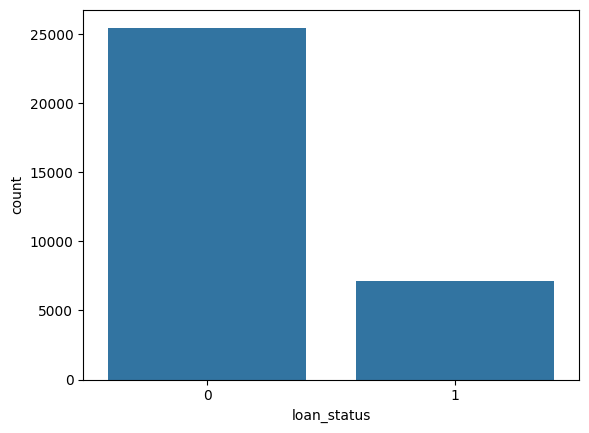

In [93]:
print(financialDF['loan_status'].value_counts())
sns.countplot(x='loan_status', data=financialDF)
plt.show()

# Data Analysis and Cleaning

1. Removing all rows with <u>**NULL**</u> values

In [94]:
# number of empty cells per column before cleaning
print(financialDF.isnull().sum(), f"Original shape of dataframe{financialDF.shape}") # (32561,12)

# remove any row that has a missing value
financialDF.dropna(inplace=True)

print("--------------------------------------------")

# number of empty cells per column after cleaning
print(financialDF.isnull().sum(), f"Shape of updated dataframe{financialDF.shape}") # (28638, 12)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64 Original shape of dataframe(32581, 12)
--------------------------------------------
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64 Shape of updated dataframe(28638, 12)


2. Removing <u>**Duplicate**</u> values

In [95]:
financialDF.drop_duplicates(inplace=True)

print(f"Shape of updated dataframe{financialDF.shape}")

Shape of updated dataframe(28501, 12)


3. Removing any <u>**outliers**</u>

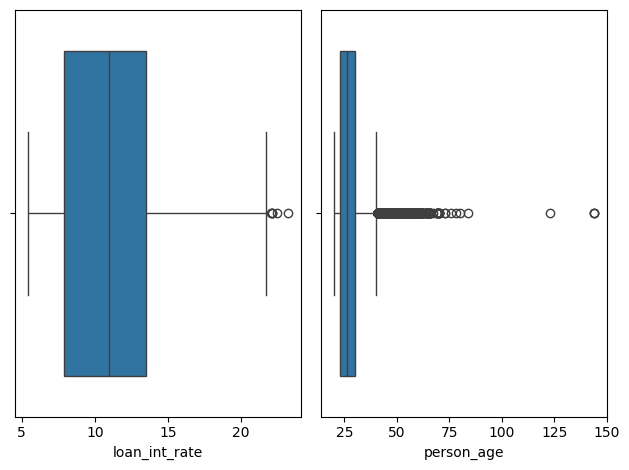

In [96]:
plt.subplot(1, 2, 1)
sns.boxplot(x=financialDF['loan_int_rate'])

plt.subplot(1, 2, 2)
sns.boxplot(x=financialDF['person_age'])

plt.tight_layout()
plt.show()

We can observe that there are some extreme/unrealistic outliers for the age. Thus, I will remove the outliers for any age > 120

In [97]:
# remove outliers

print("Shape before dealing with outliers: ", financialDF.shape)

financialDF = financialDF[financialDF["person_age"] <= 100]
financialDF = financialDF[financialDF["person_emp_length"] <= 60]

income_99th = financialDF["person_income"].quantile(0.99)
financialDF["person_income"] = np.where(financialDF["person_income"] > income_99th, income_99th, financialDF["person_income"])

print("Shape after dealing with outliers: ", financialDF.shape)


Shape before dealing with outliers:  (28501, 12)
Shape after dealing with outliers:  (28495, 12)


# Exploratory Data Analysis

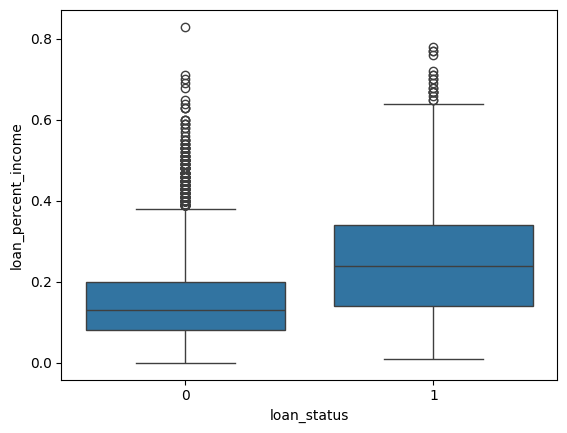

In [98]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=financialDF)
plt.show()

<Axes: xlabel='loan_grade', ylabel='count'>

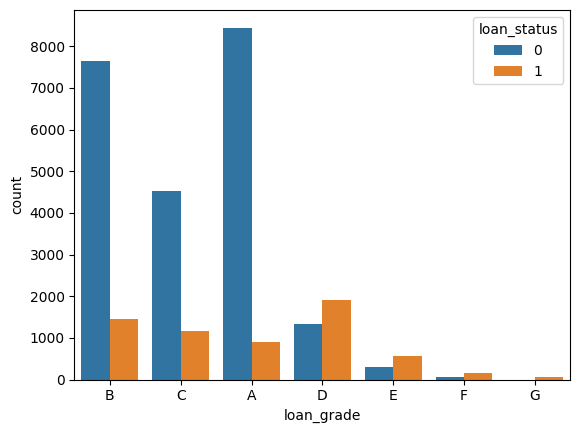

In [99]:
sns.countplot(x='loan_grade', hue='loan_status', data=financialDF)

<Axes: >

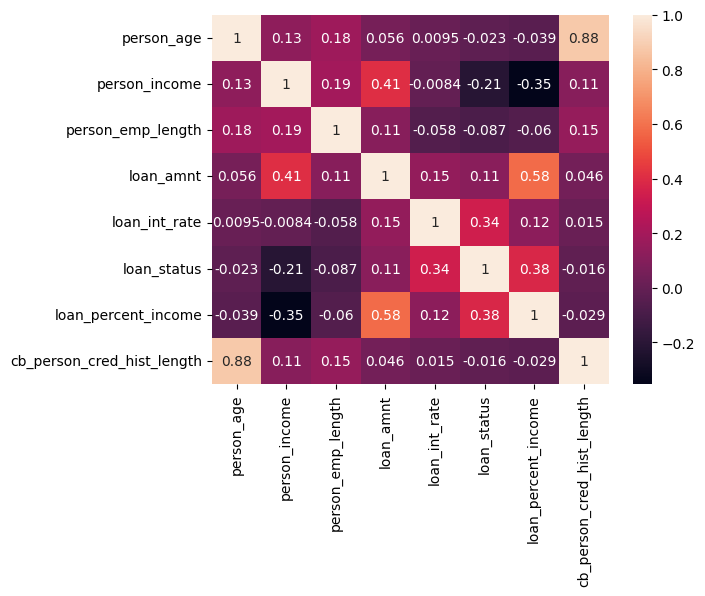

In [100]:
corr = financialDF.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

Creating a correlation heatmap of the dataset shows that for "loan_status", factors that show a strong correlation include: 
1. <u><b>loan_percent_income</b></u> (Positive Correlation): Those whose loan is a larger percent of their income are more likely to default on a loan
2. <u><b>loan_int_rate</b></u> (Positive Correlation): The higher the interest rate of a person, the more likely they are to default on their loan
3. <u><b>person_income</b></u> (Negative Correlation): The more someone makes, the less likely they are to defaulr on their loan
4. <u><b>loan_amount</b></u> (Positive Correlation): The higher the loan amount, the more likely the person is to default on the loan

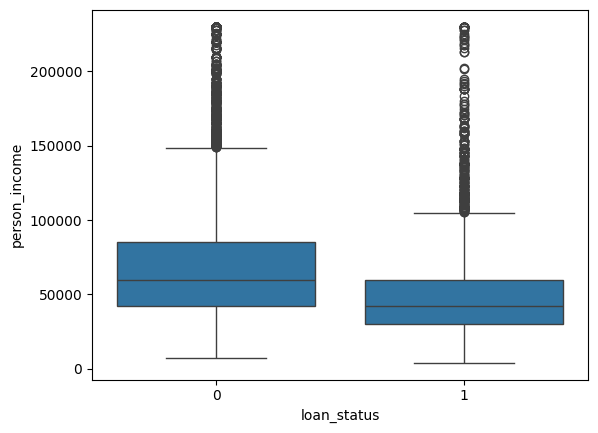

In [101]:
sns.boxplot(x='loan_status', y='person_income', data=financialDF)
plt.show()


Observation: Dafulters tend to have lower income compared to those who don't defualt. Furthermore, huge number of outliers reveals that the data is right skewed.

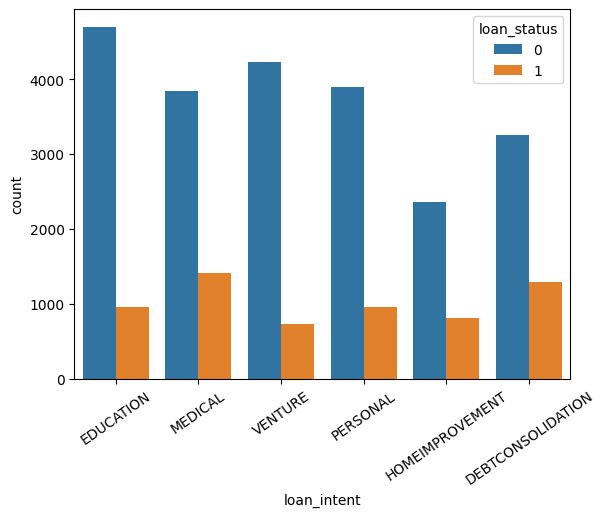

In [102]:
# loan status vs loan intent
sns.countplot(x='loan_intent', hue='loan_status', data=financialDF)
plt.xticks(rotation = 35)
plt.show()

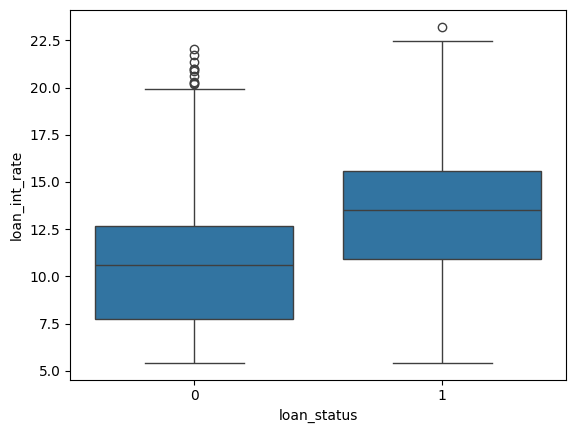

In [103]:
# loan interest rate vs loan status
sns.boxplot(x='loan_status', y='loan_int_rate', data=financialDF)
plt.show()

Observation: Those who did not default generally had a lower interest rate. This suggests that a higher interest rate is associated with an increased default risk.

# Model Training and Analysis

### Logistic Regression

I choose to use Logistic Regression, which is a statistical model and classigication algorithm, as I am trying to predict a discrete category, namely loan_status.

In [110]:
# every attribute which could contribute to the prediction
X = financialDF.drop('loan_status', axis=1)

# attribute to predict
y = financialDF['loan_status']


# this encodes the object/categorical variables, so the model can deal with these values
X = pd.get_dummies(X, drop_first=True)

# 60/40 training/testing split
# random_state ensures reproductability
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


# standardizes features because Logistic Regression is sensitive to Feature Magnitude
scaler_var = StandardScaler()
X_train = scaler_var.fit_transform(X_train)
X_test = scaler_var.transform(X_test)


In [ ]:

# Traing the Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)


# Make the prediction for the testing dataset
y_pred = lr_model.predict(X_test)


array([0, 0, 0, ..., 1, 0, 0], shape=(11398,))

### Evalute the performance of the Logistic Regression Model

In [ ]:
# Accuracy:
acc = accuracy_score(y_test, y_pred) * 100
print(f"accuracy: {round(acc, 2)}%\n")
print(f"Precentage of non-defults: {len(financialDF[financialDF["loan_status"] == 0])/len(financialDF["loan_status"])}\n")
# print(f"Precentage of defults: {}")

# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), end="\n")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


y_scores = lr_model.predict_proba(X_test)[:, 1]

precision, recall, threshold = precision_recall_curve(y_test, y_scores)

auc_score = auc(recall, precision)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Threshold: {threshold}\n")

print(f"auc_score: {auc_score}")

accuracy: 86.66%

Precentage of non-defults: 0.7828741884541147
Confusion Matrix:
[[8485  416]
 [1104 1393]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      8901
           1       0.77      0.56      0.65      2497

    accuracy                           0.87     11398
   macro avg       0.83      0.76      0.78     11398
weighted avg       0.86      0.87      0.86     11398

Precision: [0.21907352 0.21909274 0.21911197 ... 1.         1.         1.        ]
Recall: [1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 8.00961153e-04
 4.00480577e-04 0.00000000e+00]
Threshold: [2.52960322e-04 8.37419074e-04 9.26158841e-04 ... 9.99645373e-01
 9.99715240e-01 9.99814987e-01]

auc_score: 0.7300778955437346


/var/folders/qm/w6dbq0kd6tb78c2rm_8fhc7w0000gn/T/ipykernel_58107/1244753958.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


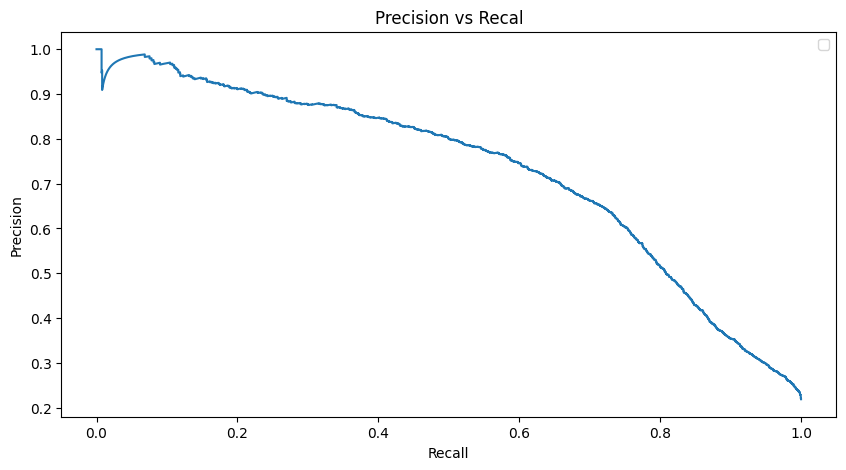

In [115]:
plt.figure(figsize=(10, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recal')
plt.legend()
plt.show()

### Decision Tree

In [ ]:
# Using GridSearch along with the DecisionTreeClassifier to test multiple max_depths and select the best performing option through cross-validation
# dealing with the best max_depth to prevent overfitting

tree_model = DecisionTreeClassifier(random_state=5)

# list of depths to test
depth_test = {'max_depth' : [2, 3, 5, 7, 9, 10, None]}

# split dataset into 5 parts to validate each depth
determined_depth = GridSearchCV(estimator=tree_model, param_grid=depth_test, cv = 5)

# fitting the data
determined_depth.fit(X_train, y_train)

# finding the best depth
print(f"Best Depth: {determined_depth.best_params_['max_depth']}")

dt_prediction = determined_depth.predict(X_test)

dt_prediction


Best Depth: 10


array([0, 0, 0, ..., 1, 0, 0], shape=(11398,))

### Random Forest

In [109]:
# TODO: Include a Random Forest Algorithm

rf_model = RandomForestClassifier(n_estimators=100, random_state=1)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_prediction

array([0, 0, 0, ..., 1, 0, 0], shape=(11398,))